In [15]:
import pandas as pd
df = pd.read_csv("/content/data_amazon.xlsx - Sheet1.csv", engine='python', on_bad_lines='warn')
print(df.shape)
print(df.columns.tolist())
print(df.isna().sum())
print(df.head())

(49338, 9)
['Title', 'Review', 'Cons_rating', 'Cloth_class', 'Materials', 'Construction', 'Color', 'Finishing', 'Durability']
Title            3968
Review            831
Cons_rating       214
Cloth_class        16
Materials       43597
Construction    43595
Color           43596
Finishing       43601
Durability      43604
dtype: int64
                     Title                                             Review  \
0                      NaN  Absolutely wonderful - silky and sexy and comf...   
1                      NaN  Love this dress!  it's sooo pretty.  i happene...   
2  Some major design flaws  I had such high hopes for this dress and reall...   
3         My favorite buy!  I love, love, love this jumpsuit. it's fun, fl...   
4         Flattering shirt  This shirt is very flattering to all due to th...   

   Cons_rating Cloth_class  Materials  Construction  Color  Finishing  \
0          4.0   Intimates        0.0           0.0    0.0        1.0   
1          5.0     Dresses    

In [16]:
# Drop rows with no review text or rating
df = df.dropna(subset=["Review", "Cons_rating"]).copy()
df["Title"] = df["Title"].fillna("")

# Combine title + review as one input
df["text"] = (df["Title"] + ". " + df["Review"]).str.strip()

# Confirm the rating scale first
print(df["Cons_rating"].value_counts().sort_index())

# 3-class labels
def to_label(r):
    if r <= 2: return 0   # negative
    if r == 3: return 1   # neutral
    return 2              # positive

df["label"] = df["Cons_rating"].apply(to_label)
print(df["label"].value_counts(normalize=True))
print(df.shape)

Cons_rating
1.0     3798
2.0     3303
3.0     5307
4.0     8104
5.0    27783
Name: count, dtype: int64
label
2    0.743079
0    0.147034
1    0.109887
Name: proportion, dtype: float64
(48295, 11)


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

train, test = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

vec = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
Xtr = vec.fit_transform(train["text"])
Xte = vec.transform(test["text"])

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(Xtr, train["label"])
print(classification_report(test["label"], clf.predict(Xte)))

              precision    recall  f1-score   support

           0       0.66      0.71      0.68      1420
           1       0.36      0.55      0.44      1062
           2       0.97      0.87      0.92      7177

    accuracy                           0.82      9659
   macro avg       0.66      0.71      0.68      9659
weighted avg       0.85      0.82      0.83      9659



In [17]:
!pip install -q transformers datasets accelerate


In [18]:
import torch, numpy as np
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

model_name = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(model_name)

# Hold out a validation set from train (test stays untouched until the end)
tr, val = train_test_split(train, test_size=0.1, stratify=train["label"], random_state=42)

def to_ds(d):
    ds = Dataset.from_pandas(d[["text", "label"]].reset_index(drop=True))
    return ds.map(lambda b: tok(b["text"], truncation=True, max_length=128),
                  batched=True, remove_columns=["text"])

tr_ds, val_ds, te_ds = to_ds(tr), to_ds(val), to_ds(test)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/34772 [00:00<?, ? examples/s]

Map:   0%|          | 0/3864 [00:00<?, ? examples/s]

Map:   0%|          | 0/9659 [00:00<?, ? examples/s]

In [19]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Same idea as class_weight="balanced" in your baseline
w = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=tr["label"])
weights = torch.tensor(w, dtype=torch.float).to("cuda")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = torch.nn.functional.cross_entropy(outputs.logits, labels, weight=weights)
        return (loss, outputs) if return_outputs else loss

def metrics(p):
    preds = p.predictions.argmax(-1)
    return {"macro_f1": f1_score(p.label_ids, preds, average="macro"),
            "accuracy": accuracy_score(p.label_ids, preds)}

args = TrainingArguments(
    output_dir="distilbert-reviews",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    fp16=True,
    report_to="none",
)

trainer = WeightedTrainer(model=model, args=args, train_dataset=tr_ds,
                          eval_dataset=val_ds, data_collator=DataCollatorWithPadding(tok),
                          compute_metrics=metrics)
trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.584721,0.560963,0.699278,0.819617
2,0.487980,0.586734,0.720019,0.842391
3,0.402153,0.631599,0.712965,0.843685


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3261, training_loss=0.5050343195012433, metrics={'train_runtime': 414.0436, 'train_samples_per_second': 251.944, 'train_steps_per_second': 7.876, 'total_flos': 3443748072620400.0, 'train_loss': 0.5050343195012433, 'epoch': 3.0})

              precision    recall  f1-score   support

         neg       0.76      0.70      0.73      1420
         neu       0.39      0.67      0.49      1062
         pos       0.98      0.89      0.93      7177

    accuracy                           0.84      9659
   macro avg       0.71      0.75      0.72      9659
weighted avg       0.88      0.84      0.85      9659



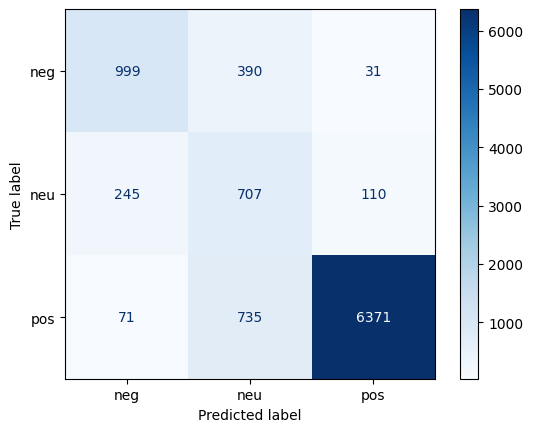

In [20]:
out = trainer.predict(te_ds)
preds = out.predictions.argmax(-1)
print(classification_report(test["label"], preds, target_names=["neg", "neu", "pos"]))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(test["label"], preds)
ConfusionMatrixDisplay(cm, display_labels=["neg", "neu", "pos"]).plot(cmap="Blues")
plt.show()

In [21]:
trainer.save_model("/content/best_model")
tok.save_pretrained("/content/best_model")

from google.colab import drive
drive.mount('/content/drive')
!cp -r /content/best_model /content/drive/MyDrive/distilbert_reviews_model

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
test = test.reset_index(drop=True)
test["pred"] = preds
test["correct"] = test["pred"] == test["label"]

# 1. Which star ratings get predicted as what?
print(pd.crosstab(test["Cons_rating"], test["pred"], normalize="index").round(2))

# 2. Accuracy by clothing category
print(test.groupby("Cloth_class")["correct"].agg(["mean", "count"]).sort_values("mean"))

# 3. Read the biggest error group: true positive, predicted neutral
errs = test[(test["label"] == 2) & (test["pred"] == 1)]
for t in errs.sample(8, random_state=1)["text"]:
    print("-", t[:300], "\n")

pred            0     1     2
Cons_rating                  
1.0          0.84  0.15  0.01
2.0          0.55  0.41  0.03
3.0          0.23  0.67  0.10
4.0          0.02  0.32  0.65
5.0          0.01  0.04  0.96
                 mean  count
Cloth_class                 
Trend        0.685714     35
Intimates    0.761905     21
Outerwear    0.771930     57
Shorts       0.811287    567
Pants        0.813245    755
Shirts       0.814050    484
Swim         0.819672     61
Blouses      0.820677   1093
Skirts       0.821429    168
Dresses      0.834835   1665
Lounge       0.835616    146
Knits        0.835631    943
Jeans        0.840252    795
Blazer       0.840731    383
Legwear      0.840909     44
Sweaters     0.847010    719
Fine gauge   0.850467    214
Jackets      0.859281    668
Suits        0.885714    245
Sleep        0.887916    571
Layering     0.950000     20
Dress        1.000000      3
- . Super cute style but runs slightly larger then other ag jeans i have. 

- Little longer th

In [23]:
errs = test[(test["label"] == 2) & (test["pred"] == 1)]
ok_pos = test[(test["label"] == 2) & (test["pred"] == 2)]

print(errs["Cons_rating"].value_counts(normalize=True).round(2))

contrast = r"\b(but|however|although|though|unfortunately)\b"
fit = r"\b(size|fit|fits|large|small|tight|loose|long|short|length|petite|tall)\b"
rate = lambda s, p: s.str.lower().str.contains(p, regex=True).mean().round(2)

print("contrast word:", rate(errs["text"], contrast), "errors vs", rate(ok_pos["text"], contrast), "correct")
print("fit/size word:", rate(errs["text"], fit), "errors vs", rate(ok_pos["text"], fit), "correct")
print("median words:", errs["text"].str.split().str.len().median(),
      "errors vs", ok_pos["text"].str.split().str.len().median(), "correct")

Cons_rating
4.0    0.73
5.0    0.27
Name: proportion, dtype: float64
contrast word: 0.76 errors vs 0.36 correct
fit/size word: 0.76 errors vs 0.61 correct
median words: 50.0 errors vs 34.0 correct


/tmp/ipykernel_830/1760052042.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  rate = lambda s, p: s.str.lower().str.contains(p, regex=True).mean().round(2)


In [24]:
!pip install -q shap

In [25]:
import shap
from transformers import pipeline

pipe = pipeline("text-classification", model="/content/best_model",
                tokenizer="/content/best_model", top_k=None, device=0,
                truncation=True, max_length=128)

explainer = shap.Explainer(pipe)

# Three misclassified positive reviews, trimmed for speed
samples = [t[:500] for t in errs.sample(3, random_state=1)["text"]]
sv = explainer(samples)

shap.plots.text(sv[0])

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  0%|          | 0/272 [00:00<?, ?it/s]

PartitionExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [00:25<00:00,  2.64s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:34, 11.44s/it]


In [26]:
print(errs.sample(3, random_state=1)[["Cons_rating", "Cloth_class"]])

shap.plots.text(sv[1])
shap.plots.text(sv[2])

      Cons_rating Cloth_class
6974          5.0       Jeans
8262          4.0      Shorts
1780          4.0       Knits


In [27]:
from huggingface_hub import notebook_login
notebook_login()   # paste the token in the box that appears

In [28]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained("/content/best_model")
tok = AutoTokenizer.from_pretrained("/content/best_model")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [29]:
from google.colab import drive
drive.mount('/content/drive')

from transformers import AutoModelForSequenceClassification, AutoTokenizer

path = "/content/drive/MyDrive/distilbert_reviews_model"
model = AutoModelForSequenceClassification.from_pretrained(path)
tok = AutoTokenizer.from_pretrained(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [30]:
model.config.id2label = {0: "negative", 1: "neutral", 2: "positive"}
model.config.label2id = {"negative": 0, "neutral": 1, "positive": 2}

repo = "MilindSingh316/distilbert-clothing-review-sentiment"
model.push_to_hub(repo)
tok.push_to_hub(repo)

README.md:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ngw9f07/model.safetensors:   6%|5         | 15.9MB /  268MB            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/MilindSingh316/distilbert-clothing-review-sentiment/commit/ca81af7bc3f475dddd790a3cb0a21345bdd68a39', commit_message='Upload tokenizer', commit_description='', oid='ca81af7bc3f475dddd790a3cb0a21345bdd68a39', pr_url=None, repo_url=RepoUrl('https://huggingface.co/MilindSingh316/distilbert-clothing-review-sentiment', endpoint='https://huggingface.co', repo_type='model', repo_id='MilindSingh316/distilbert-clothing-review-sentiment'), pr_revision=None, pr_num=None)

In [31]:
card = """---
license: apache-2.0
base_model: distilbert-base-uncased
tags:
- text-classification
- sentiment-analysis
---

# Clothing Review Sentiment Classifier

Fine-tuned DistilBERT for 3-class sentiment classification (negative/neutral/positive)
on ~48k clothing reviews from Kaggle ("Consumer Review of Clothing", Jocelyn Dumlao).

## Results (test set, n=9,659)

| Model | Macro F1 | Accuracy |
|---|---|---|
| TF-IDF + Logistic Regression (baseline) | 0.68 | 0.82 |
| DistilBERT (this model) | 0.72 | 0.84 |

## Error analysis

Most errors occur at class boundaries, particularly 4-star reviews predicted as neutral.
72% of these errors are 4-star reviews, and 76% contain contrast words ("but", "however")
vs 36% of correctly classified positives — suggesting the model is reasonably picking up
on genuinely mixed sentiment (praise + a caveat) rather than making random mistakes.
Some errors likely trace to label noise (e.g. reviews describing returns or damage rated 4-5 stars).

## Labels
0 = negative, 1 = neutral, 2 = positive

## Training
- Base model: distilbert-base-uncased
- 3 epochs, best checkpoint at epoch 2 (by validation macro F1)
- Class-weighted loss to handle imbalance (74% positive / 15% negative / 11% neutral)
- max_length=128, learning_rate=2e-5, batch_size=32
"""

with open("/content/best_model_card.md", "w") as f:
    f.write(card)

from huggingface_hub import upload_file
upload_file(
    path_or_fileobj="/content/best_model_card.md",
    path_in_repo="README.md",
    repo_id=repo,
)

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/MilindSingh316/distilbert-clothing-review-sentiment/commit/ca81af7bc3f475dddd790a3cb0a21345bdd68a39', commit_message='Upload README.md with huggingface_hub', commit_description='', oid='ca81af7bc3f475dddd790a3cb0a21345bdd68a39', pr_url=None, repo_url=RepoUrl('https://huggingface.co/MilindSingh316/distilbert-clothing-review-sentiment', endpoint='https://huggingface.co', repo_type='model', repo_id='MilindSingh316/distilbert-clothing-review-sentiment'), pr_revision=None, pr_num=None)